In [1]:
import pandas as pd
import numpy as np
import re
import nltk

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [7]:
import os
print(os.getcwd())


c:\Users\hp\Desktop\SentiScope\notebooks


In [9]:
df = pd.read_csv("../data/reviews.csv")

df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [10]:
df = df[[
    'name',
    'brand',
    'reviews.rating',
    'reviews.text',
    'reviews.title'
]]

In [11]:
df.columns = ['product', 'brand', 'rating', 'review', 'title']


In [12]:
df = df.dropna(subset=['review', 'rating'])

In [13]:
df = df.drop_duplicates()

In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

In [15]:
df['clean_review'] = df['review'].apply(clean_text)

In [16]:
df.to_csv("../data/cleaned_reviews.csv", index=False)

In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1164 entries, 0 to 1596
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       1164 non-null   object 
 1   brand         1164 non-null   object 
 2   rating        1164 non-null   float64
 3   review        1164 non-null   object 
 4   title         1164 non-null   object 
 5   clean_review  1164 non-null   object 
dtypes: float64(1), object(5)
memory usage: 63.7+ KB


,rating
count,1164.000000
mean,4.361684
std,1.016938
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


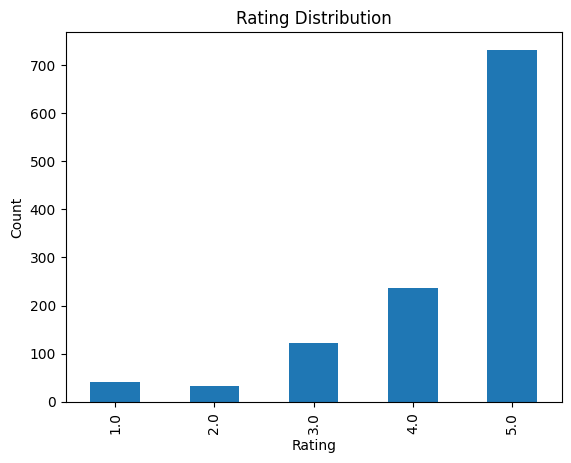

In [18]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

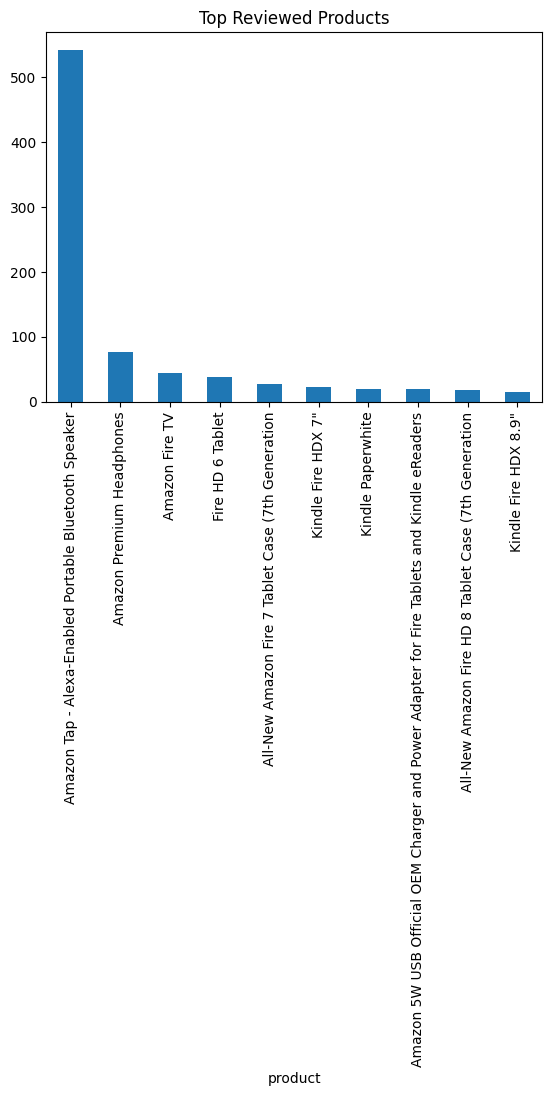

In [19]:
top_products = df['product'].value_counts().head(10)

top_products.plot(kind='bar')
plt.title("Top Reviewed Products")
plt.show()

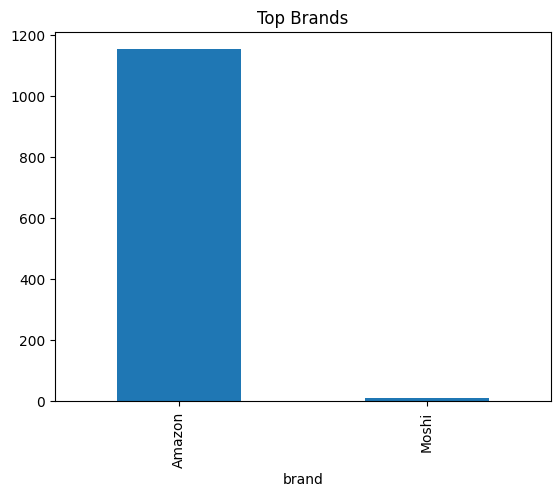

In [20]:
top_brands = df['brand'].value_counts().head(10)

top_brands.plot(kind='bar')
plt.title("Top Brands")
plt.show()

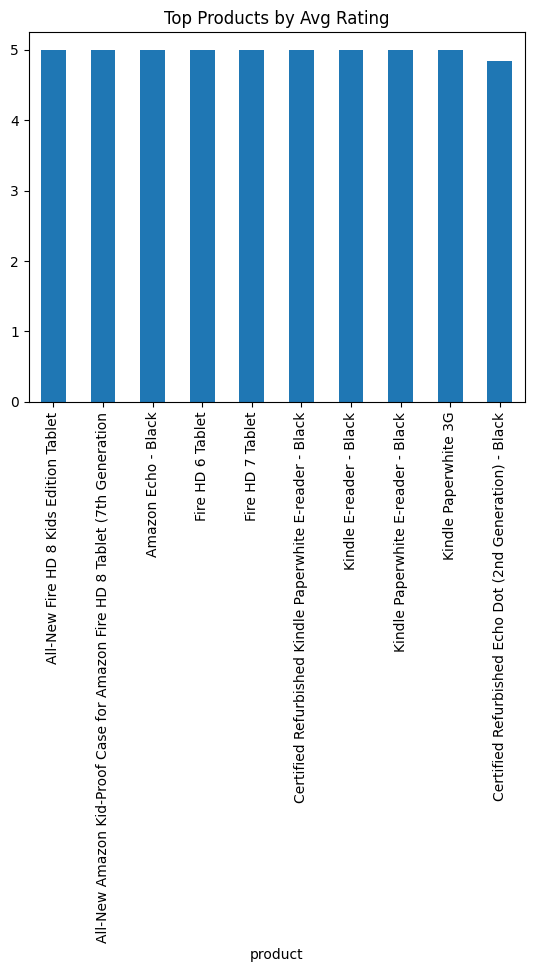

In [21]:
avg_rating = df.groupby('product')['rating'].mean().sort_values(ascending=False).head(10)

avg_rating.plot(kind='bar')
plt.title("Top Products by Avg Rating")
plt.show()

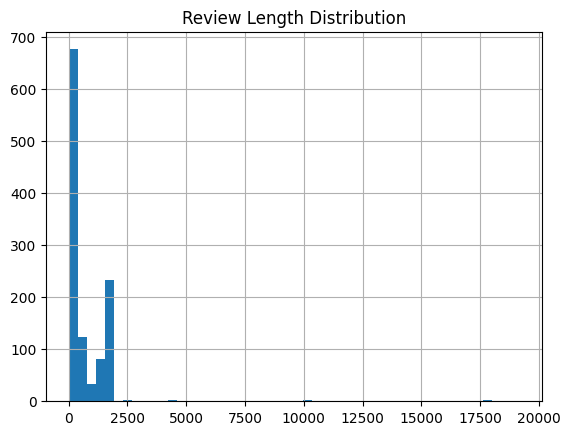

In [22]:
df['review_length'] = df['clean_review'].apply(len)

df['review_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

In [23]:
from textblob import TextBlob

In [24]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [25]:
df['sentiment_score'] = df['clean_review'].apply(get_sentiment)

In [26]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(label_sentiment)

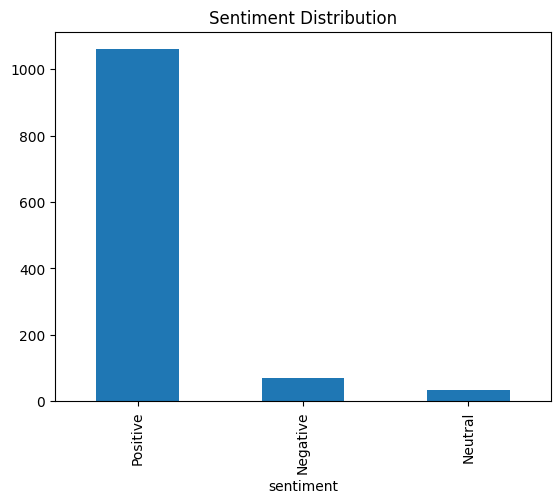

In [27]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

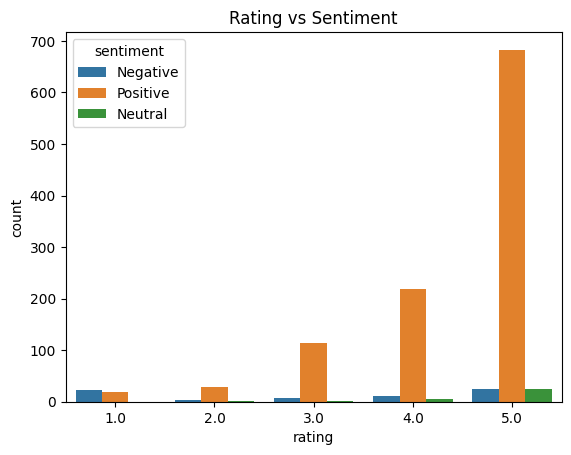

In [28]:
import seaborn as sns

sns.countplot(x='rating', hue='sentiment', data=df)
plt.title("Rating vs Sentiment")
plt.show()

In [29]:
aspects = {
    "battery": ["battery", "charge", "power"],
    "delivery": ["delivery", "shipping", "late"],
    "price": ["price", "cost", "expensive", "cheap"],
    "quality": ["quality", "build", "material"],
    "design": ["design", "look", "style"]
}

In [30]:
def detect_aspects(text):
    found = []
    
    for aspect, keywords in aspects.items():
        for word in keywords:
            if word in text:
                found.append(aspect)
                break
                
    return found

In [31]:
df['aspects'] = df['clean_review'].apply(detect_aspects)

In [32]:
negative_df = df[df['sentiment'] == "Negative"]

In [33]:
from collections import Counter

all_aspects = []

for row in negative_df['aspects']:
    all_aspects.extend(row)

aspect_counts = Counter(all_aspects)

print(aspect_counts)

Counter({'price': 12, 'battery': 9, 'design': 8, 'quality': 3, 'delivery': 3})


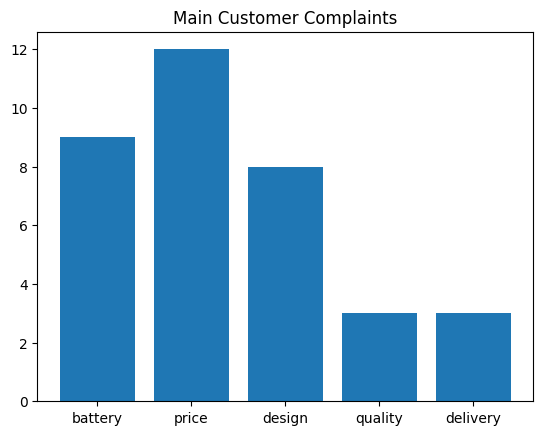

In [34]:
import matplotlib.pyplot as plt

plt.bar(aspect_counts.keys(), aspect_counts.values())
plt.title("Main Customer Complaints")
plt.show()

In [35]:
df.to_csv("../data/final_reviews.csv", index=False)

In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    score = analyzer.polarity_scores(text)
    return score['compound']